# Datathon – Fase 5 (Postech) – Notebook de Análise + Modelo de Risco

esse notebook aqui é um **esqueleto completo** com os tópicos do enunciado (perguntas 1–11) + a parte de **Machine Learning** (previsão de risco de defasagem).

**Como usar**
1. Rode as células em ordem.
2. Onde tiver **TODO**, tu preenche com teu texto/decisão (por ex.: como vai definir “risco”).
3. No final, tu vai ter: análise, gráficos, e um modelo treinado exportável (`joblib`).

---


## 0) Setup

Vamos importar libs, ajustar opções e definir caminhos pros arquivos.


In [ ]:
# Imports
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

# ML
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)

import joblib

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

DATA_PATH = Path('/content/BASE DE DADOS PEDE 2024 - DATATHON.xlsx')

assert DATA_PATH.exists(), f'Arquivo nao encontrado: {DATA_PATH}'


## 1) Carregamento dos dados

A base vem em **3 abas** (2022, 2023, 2024). A ideia é padronizar colunas e concatenar tudo num único dataframe.


In [ ]:
# Ler todas as abas
xls = pd.ExcelFile(DATA_PATH)
print('Sheets:', xls.sheet_names)

dfs = {}
for sh in xls.sheet_names:
    dfs[sh] = xls.parse(sh)
    print(sh, dfs[sh].shape)

# Preview
for sh, df_ in dfs.items():
    print('===', sh, '===')
    display(df_.head(3))

Sheets: ['PEDE2022', 'PEDE2023', 'PEDE2024']
PEDE2022 (860, 42)
PEDE2023 (1014, 48)
PEDE2024 (1156, 50)
=== PEDE2022 ===


,RA,Fase,Turma,Nome,Ano nasc,Idade 22,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,Pedra 21,Pedra 22,INDE 22,Cg,Cf,Ct,Nº Av,Avaliador1,Rec Av1,Avaliador2,Rec Av2,Avaliador3,Rec Av3,Avaliador4,Rec Av4,IAA,IEG,IPS,Rec Psicologia,IDA,Matem,Portug,Inglês,Indicado,Atingiu PV,IPV,IAN,Fase ideal,Defas,Destaque IEG,Destaque IDA,Destaque IPV
0,RA-1,7,A,Aluno-1,2003,19,Menina,2016,Escola Pública,Ametista,Ametista,Quartzo,5.783,753,18,10,4,Avaliador-5,Mantido na Fase atual,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Mantido na Fase atual,8.3,4.1,5.6,Requer avaliação,4.0,2.7,3.5,6.0,Sim,Não,7.278,5.0,Fase 8 (Universitários),-1,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
1,RA-2,7,A,Aluno-2,2005,17,Menina,2017,Rede Decisão,Ametista,Ametista,Ametista,7.055,469,8,3,4,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Promovido de Fase + Bolsa,8.8,5.2,6.3,Sem limitações,6.8,6.3,4.5,9.7,Não,Não,6.778,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
2,RA-3,7,A,Aluno-3,2005,17,Menina,2016,Rede Decisão,Ametista,Ametista,Ágata,6.591,629,13,6,4,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase + Bolsa,Avaliador-31,Promovido de Fase + Bolsa,0.0,7.9,5.6,Sem limitações,5.6,5.8,4.0,6.9,Não,Não,7.556,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...


=== PEDE2023 ===


,RA,Fase,INDE 2023,Pedra 2023,Turma,Nome Anonimizado,Data de Nasc,Idade,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,Pedra 21,Pedra 22,Pedra 23,INDE 22,INDE 23,Cg,Cf,Ct,Nº Av,Avaliador1,Rec Av1,Avaliador2,Rec Av2,Avaliador3,Rec Av3,Avaliador4,Rec Av4,IAA,IEG,IPS,IPP,Rec Psicologia,IDA,Mat,Por,Ing,Indicado,Atingiu PV,IPV,IAN,Fase Ideal,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,Destaque IPV.1
0,RA-861,ALFA,9.31095,Topázio,ALFA A - G0/G1,Aluno-861,6/17/2015,8,Feminino,2023,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,Avaliador-11,NaN,Avaliador-2,NaN,NaN,NaN,NaN,NaN,9.5,10.0,8.13,8.4375,NaN,9.6,9.8,9.4,NaN,NaN,NaN,8.920,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN
1,RA-862,ALFA,8.22120,Topázio,ALFA A - G0/G1,Aluno-862,5/31/2014,9,Masculino,2023,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,Avaliador-11,NaN,Avaliador-2,NaN,NaN,NaN,NaN,NaN,8.5,9.1,8.14,7.5000,NaN,8.9,8.5,9.2,NaN,NaN,NaN,8.585,5.0,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,NaN
2,RA-863,ALFA,5.92975,Quartzo,ALFA A - G0/G1,Aluno-863,2/25/2016,7,Masculino,2023,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,Avaliador-11,NaN,Avaliador-2,NaN,NaN,NaN,NaN,NaN,0.0,7.6,3.14,5.9375,NaN,6.3,7.0,5.5,NaN,NaN,NaN,6.260,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN


=== PEDE2024 ===


,RA,Fase,INDE 2024,Pedra 2024,Turma,Nome Anonimizado,Data de Nasc,Idade,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,Pedra 21,Pedra 22,Pedra 23,INDE 22,INDE 23,Cg,Cf,Ct,Nº Av,Avaliador1,Rec Av1,Avaliador2,Rec Av2,Avaliador3,Avaliador4,Avaliador5,Avaliador6,IAA,IEG,IPS,IPP,Rec Psicologia,IDA,Mat,Por,Ing,Indicado,Atingiu PV,IPV,IAN,Fase Ideal,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,Escola,Ativo/ Inativo,Ativo/ Inativo.1
0,RA-1275,ALFA,7.611367,Ametista,ALFA A - G0/G1,Aluno-1275,2016-07-28,8,Masculino,2024,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,Avaliador-11,NaN,Avaliador-2,NaN,Avaliador-9,NaN,NaN,NaN,10.002,8.666667,6.26,5.625,NaN,8.0,10.0,6.0,NaN,NaN,NaN,5.446667,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando
1,RA-1276,ALFA,8.002867,Topázio,ALFA A - G0/G1,Aluno-1276,2016-10-16,8,Feminino,2024,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,Avaliador-11,NaN,Avaliador-2,NaN,Avaliador-9,NaN,NaN,NaN,10.002,9.333333,3.76,7.500,NaN,8.0,10.0,6.0,NaN,NaN,NaN,7.050000,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando
2,RA-1277,ALFA,7.9522,Ametista,ALFA A - G0/G1,Aluno-1277,2016-08-16,8,Masculino,2024,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,Avaliador-11,NaN,Avaliador-2,NaN,Avaliador-9,NaN,NaN,NaN,10.002,9.083333,3.76,7.500,NaN,8.0,10.0,6.0,NaN,NaN,NaN,7.046667,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Dom Pedro Villas Boas de Souza,Cursando,Cursando


## 2) Padronização e união (2022–2024)

Aqui tu vai:
- Criar uma coluna **ano_ref** (2022/2023/2024)
- Renomear colunas que mudaram de nome entre anos (ex.: `INDE 22`, `INDE 23`, `INDE 2024`)
- Garantir que `Fase`, `Turma`, `Gênero`, `Instituição de ensino` etc. fiquem consistentes

> **Honestidade bruta:** se tu não padronizar isso direito, o resto vira areia movediça.


In [ ]:
# Função util pra normalizar nomes

def normalize_columns(df):
    out = df.copy()
    out.columns = [c.strip() for c in out.columns]
    return out

p22 = normalize_columns(dfs['PEDE2022']).copy()
p23 = normalize_columns(dfs['PEDE2023']).copy()
p24 = normalize_columns(dfs['PEDE2024']).copy()

p22['ano_ref'] = 2022
p23['ano_ref'] = 2023
p24['ano_ref'] = 2024

# Padronizar alguns nomes comuns
rename_22 = {
    'Nome': 'Nome_Anon',
    'Ano nasc': 'Ano_Nasc',
    'Idade 22': 'Idade',
    'Instituição de ensino': 'Instituicao_Ensino',
    'INDE 22': 'INDE',
}
rename_23 = {
    'Nome Anonimizado': 'Nome_Anon',
    'Data de Nasc': 'Data_Nasc',
    'Instituição de ensino': 'Instituicao_Ensino',
    'INDE 23': 'INDE',
}
rename_24 = {
    'Nome Anonimizado': 'Nome_Anon',
    'Data de Nasc': 'Data_Nasc',
    'Instituição de ensino': 'Instituicao_Ensino',
    'INDE 2024': 'INDE',
}

p22 = p22.rename(columns=rename_22)
p23 = p23.rename(columns=rename_23)
p24 = p24.rename(columns=rename_24)

# Padronizar notas de disciplinas
p22 = p22.rename(columns={'Matem': 'Mat', 'Portug': 'Por', 'Inglês': 'Ing'})

# Garantir colunas-chave existam
for df_ in (p22, p23, p24):
    for col in ['RA','Fase','Turma','Gênero','Ano ingresso','Instituicao_Ensino','INDE','IAA','IEG','IPS','IDA','IPV','IAN','Defasagem','Fase Ideal','IPP']:
        if col not in df_.columns:
            df_[col] = np.nan

# Unir
base = pd.concat([p22, p23, p24], ignore_index=True)

# Ajustes finais de tipos
base['RA'] = base['RA'].astype(str)
base['ano_ref'] = base['ano_ref'].astype(int)

# Datas (quando existir)
if 'Data_Nasc' in base.columns:
    base['Data_Nasc'] = pd.to_datetime(base['Data_Nasc'], errors='coerce')

# Padronizar genero (tem "Menina"/"Feminino" etc)
base['Gênero'] = base['Gênero'].astype(str).str.strip().replace({'Feminino':'Menina','Masculino':'Menino'})

print('Base unificada:', base.shape)
display(base.head())


Base unificada: (3030, 59)


,RA,Fase,Turma,Nome_Anon,Ano_Nasc,Idade,Gênero,Ano ingresso,Instituicao_Ensino,Pedra 20,Pedra 21,Pedra 22,INDE,Cg,Cf,Ct,Nº Av,Avaliador1,Rec Av1,Avaliador2,Rec Av2,Avaliador3,Rec Av3,Avaliador4,Rec Av4,IAA,IEG,IPS,Rec Psicologia,IDA,Mat,Por,Ing,Indicado,Atingiu PV,IPV,IAN,Fase ideal,Defas,Destaque IEG,Destaque IDA,Destaque IPV,ano_ref,Defasagem,Fase Ideal,IPP,INDE 2023,Pedra 2023,Data_Nasc,Pedra 23,INDE 22,Destaque IPV.1,Pedra 2024,INDE 23,Avaliador5,Avaliador6,Escola,Ativo/ Inativo,Ativo/ Inativo.1
0,RA-1,7,A,Aluno-1,2003.0,19,Menina,2016,Escola Pública,Ametista,Ametista,Quartzo,5.783,753.0,18.0,10.0,4.0,Avaliador-5,Mantido na Fase atual,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Mantido na Fase atual,8.3,4.1,5.6,Requer avaliação,4.0,2.7,3.5,6.0,Sim,Não,7.278,5.0,Fase 8 (Universitários),-1.0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RA-2,7,A,Aluno-2,2005.0,17,Menina,2017,Rede Decisão,Ametista,Ametista,Ametista,7.055,469.0,8.0,3.0,4.0,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Promovido de Fase + Bolsa,8.8,5.2,6.3,Sem limitações,6.8,6.3,4.5,9.7,Não,Não,6.778,10.0,Fase 7 (3º EM),0.0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,RA-3,7,A,Aluno-3,2005.0,17,Menina,2016,Rede Decisão,Ametista,Ametista,Ágata,6.591,629.0,13.0,6.0,4.0,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase + Bolsa,Avaliador-31,Promovido de Fase + Bolsa,0.0,7.9,5.6,Sem limitações,5.6,5.8,4.0,6.9,Não,Não,7.556,10.0,Fase 7 (3º EM),0.0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...,2022,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,RA-4,7,A,Aluno-4,2005.0,17,Menino,2017,Rede Decisão,Ametista,Ametista,Quartzo,5.951,731.0,15.0,7.0,4.0,Avaliador-5,Promovido de Fase,Avaliador-27,Mantido na Fase atual,Avaliador-28,Mantido na Fase atual,Avaliador-31,Mantido na Fase atual,8.8,4.5,5.6,Requer avaliação,5.0,2.8,3.5,8.7,Não,Não,5.278,10.0,Fase 7 (3º EM),0.0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,RA-5,7,A,Aluno-5,2005.0,17,Menina,2016,Rede Decisão,Ametista,Ametista,Ametista,7.427,344.0,6.0,2.0,4.0,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase + Bolsa,Avaliador-31,Promovido de Fase + Bolsa,7.9,8.6,5.6,Requer avaliação,5.2,7.0,2.9,5.7,Não,Não,7.389,10.0,Fase 7 (3º EM),0.0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3) Qualidade dos dados (sanity check)

Checklist rápido pra tu não se queimar:
- % de nulos por coluna
- duplicados por `RA`/`ano_ref`
- ranges estranhos (notas fora de 0–10 etc.)


In [ ]:
# Nulos
nulls = (base.isna().mean().sort_values(ascending=False) * 100).round(1)
display(nulls.to_frame('% nulos').head(25))

# Duplicados
dups = base.duplicated(subset=['RA','ano_ref']).sum()
print('Duplicados (RA, ano_ref):', dups)

# Ranges basicos
for c in ['INDE','IAA','IEG','IPS','IDA','IPV','IAN','Mat','Por','Ing']:
    if c in base.columns:
        s = pd.to_numeric(base[c], errors='coerce')
        print(c, 'min=', np.nanmin(s.values), 'max=', np.nanmax(s.values))


,% nulos
Destaque IPV.1,100.0
Avaliador6,99.8
Avaliador5,95.1
Rec Av4,90.2
Pedra 23,77.2
INDE 23,77.2
Pedra 20,75.1
Cg,71.6
Ct,71.6
Rec Av3,71.6


Duplicados (RA, ano_ref): 0
INDE min= 3.032 max= 9.531325
IAA min= 0.0 max= 10.002
IEG min= 0.0 max= 10.0
IPS min= 2.5 max= 10.0
IDA min= 0.0 max= 10.0
IPV min= 2.5 max= 10.01
IAN min= 2.5 max= 10.0
Mat min= 0.0 max= 10.0
Por min= 0.0 max= 10.0
Ing min= 0.0 max= 10.0


## 1) Adequacao do nivel (IAN)

Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano?

Sugestões:
- Distribuição do IAN por ano e por fase
- % moderadamente/severamente defasados (definir cortes)
- Evolução por `Fase` e `ano_ref` (como proxy de evolução)

**TODO:** definir cortes de severidade do IAN (ex.: >=7 severo, 5-6 moderado, etc.) conforme dicionário/entendimento.


,ano_ref,Fase,IAN
0,2022,0,6.802632
1,2022,1,5.742188
2,2022,2,6.403226
3,2022,3,6.993243
4,2022,4,6.480263


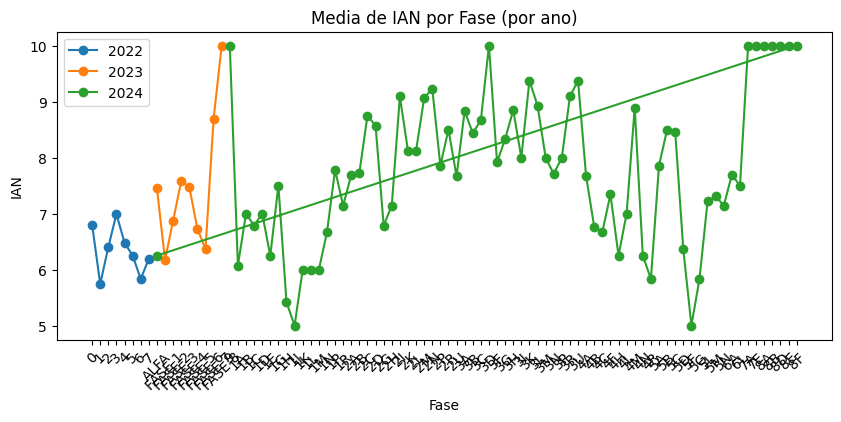

In [ ]:
# Exemplo: agregacao por ano e fase
metric = 'IAN'  # troque para 'IDA', 'INDE', etc.

tmp = base.copy()
tmp[metric] = pd.to_numeric(tmp[metric], errors='coerce')

grp = tmp.groupby(['ano_ref','Fase'])[metric].mean().reset_index()
display(grp.head())

# Plot simples
plt.figure(figsize=(10,4))
for yr, g in grp.groupby('ano_ref'):
    plt.plot(g['Fase'].astype(str), g[metric], marker='o', label=str(yr))
plt.title(f'Media de {metric} por Fase (por ano)')
plt.xlabel('Fase')
plt.ylabel(metric)
plt.legend()
plt.xticks(rotation=45)
plt.show()


## 2) Desempenho academico (IDA)

O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?

Sugestões:
- Linha/boxplot de IDA por ano e fase
- Comparar quartis por fase
- Ver se há diferenças por instituição/escola


,ano_ref,Fase,IAN
0,2022,0,6.802632
1,2022,1,5.742188
2,2022,2,6.403226
3,2022,3,6.993243
4,2022,4,6.480263


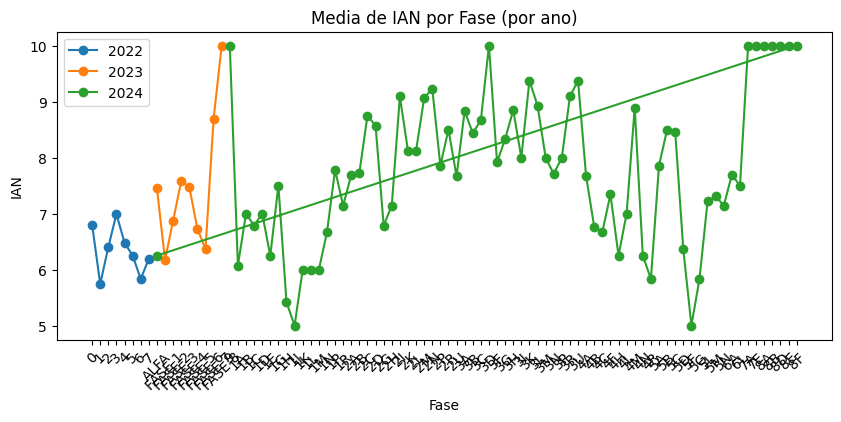

In [ ]:
# Exemplo: agregacao por ano e fase
metric = 'IAN'  # troque para 'IDA', 'INDE', etc.

tmp = base.copy()
tmp[metric] = pd.to_numeric(tmp[metric], errors='coerce')

grp = tmp.groupby(['ano_ref','Fase'])[metric].mean().reset_index()
display(grp.head())

# Plot simples
plt.figure(figsize=(10,4))
for yr, g in grp.groupby('ano_ref'):
    plt.plot(g['Fase'].astype(str), g[metric], marker='o', label=str(yr))
plt.title(f'Media de {metric} por Fase (por ano)')
plt.xlabel('Fase')
plt.ylabel(metric)
plt.legend()
plt.xticks(rotation=45)
plt.show()


## 3) Engajamento (IEG) vs desempenho (IDA/IPV)

O engajamento (IEG) tem relação direta com IDA e IPV?

Sugestões:
- Correlação (Pearson/Spearman)
- Scatter IEG vs IDA, IEG vs IPV
- Analisar por fase (segmentado)


,IEG,IDA,IPV,IAA,IPS,IPP,INDE,IAN
IEG,1.000000,0.539057,0.558200,0.133078,-0.046264,0.328542,0.789472,-0.060345
IDA,0.539057,1.000000,0.557072,0.115241,0.022485,0.369218,0.805507,0.118487
IPV,0.558200,0.557072,1.000000,0.062728,-0.048750,0.606649,0.767725,0.148880
IAA,0.133078,0.115241,0.062728,1.000000,0.157373,0.054461,0.413059,0.034162
IPS,-0.046264,0.022485,-0.048750,0.157373,1.000000,0.064209,0.230417,0.004548
IPP,0.328542,0.369218,0.606649,0.054461,0.064209,1.000000,0.637097,0.123398
INDE,0.789472,0.805507,0.767725,0.413059,0.230417,0.637097,1.000000,0.400511
IAN,-0.060345,0.118487,0.148880,0.034162,0.004548,0.123398,0.400511,1.000000


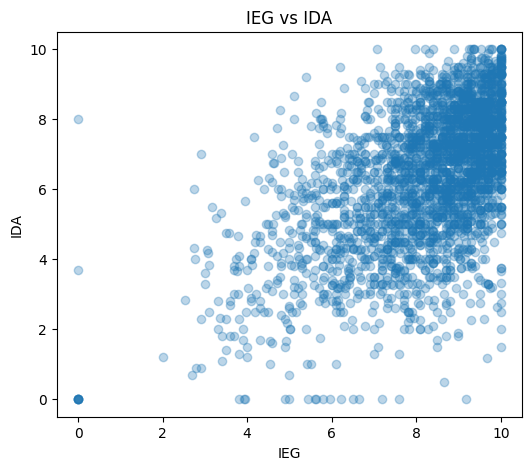

In [ ]:
# Correlacoes e scatter

def to_num(s):
    return pd.to_numeric(s, errors='coerce')

cols = ['IEG','IDA','IPV','IAA','IPS','IPP','INDE','IAN']
cols = [c for c in cols if c in base.columns]

df = base[cols].copy()
for c in cols:
    df[c] = to_num(df[c])

corr = df.corr(numeric_only=True)
display(corr)

# Scatter exemplo: IEG vs IDA
if set(['IEG','IDA']).issubset(df.columns):
    plt.figure(figsize=(6,5))
    plt.scatter(df['IEG'], df['IDA'], alpha=0.3)
    plt.title('IEG vs IDA')
    plt.xlabel('IEG')
    plt.ylabel('IDA')
    plt.show()


## 4) Autoavaliacao (IAA)

IAA é coerente com desempenho real (IDA) e engajamento (IEG)?

Sugestões:
- Correlações + scatter
- Casos extremos: alta IAA e baixo IDA (ou o contrário)


,IEG,IDA,IPV,IAA,IPS,IPP,INDE,IAN
IEG,1.000000,0.539057,0.558200,0.133078,-0.046264,0.328542,0.789472,-0.060345
IDA,0.539057,1.000000,0.557072,0.115241,0.022485,0.369218,0.805507,0.118487
IPV,0.558200,0.557072,1.000000,0.062728,-0.048750,0.606649,0.767725,0.148880
IAA,0.133078,0.115241,0.062728,1.000000,0.157373,0.054461,0.413059,0.034162
IPS,-0.046264,0.022485,-0.048750,0.157373,1.000000,0.064209,0.230417,0.004548
IPP,0.328542,0.369218,0.606649,0.054461,0.064209,1.000000,0.637097,0.123398
INDE,0.789472,0.805507,0.767725,0.413059,0.230417,0.637097,1.000000,0.400511
IAN,-0.060345,0.118487,0.148880,0.034162,0.004548,0.123398,0.400511,1.000000


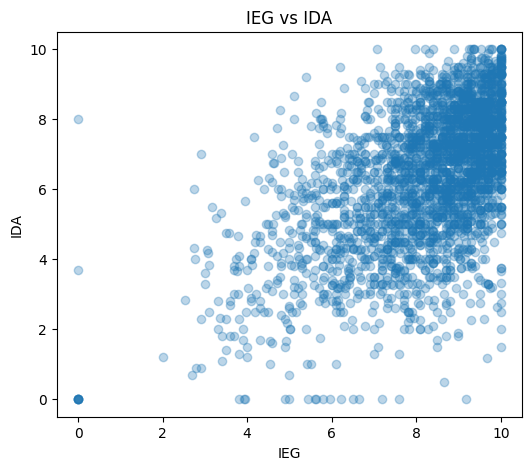

In [ ]:
# Correlacoes e scatter

def to_num(s):
    return pd.to_numeric(s, errors='coerce')

cols = ['IEG','IDA','IPV','IAA','IPS','IPP','INDE','IAN']
cols = [c for c in cols if c in base.columns]

df = base[cols].copy()
for c in cols:
    df[c] = to_num(df[c])

corr = df.corr(numeric_only=True)
display(corr)

# Scatter exemplo: IEG vs IDA
if set(['IEG','IDA']).issubset(df.columns):
    plt.figure(figsize=(6,5))
    plt.scatter(df['IEG'], df['IDA'], alpha=0.3)
    plt.title('IEG vs IDA')
    plt.xlabel('IEG')
    plt.ylabel('IDA')
    plt.show()


## 5) Aspectos psicossociais (IPS)

Há padrões em IPS que antecedem quedas de desempenho/engajamento?

Sugestões:
- IPS vs IDA/IEG por ano/fase
- Identificar grupos com IPS baixo e ver distribuição de IDA/IEG

Obs.: sem série temporal dentro do ano, tu vai usar comparações entre fases/anos como aproximação.


In [ ]:
# IPS vs IDA/IEG (analise de grupos)

tmp = base.copy()
for c in ['IPS','IDA','IEG']:
    tmp[c] = pd.to_numeric(tmp[c], errors='coerce')

# Quartis de IPS
q = tmp['IPS'].quantile([0.25,0.5,0.75])
print('Quartis IPS:', q.to_dict())

tmp['IPS_grupo'] = pd.qcut(tmp['IPS'], q=4, labels=['Q1_baixo','Q2','Q3','Q4_alto'])

agg = tmp.groupby(['ano_ref','IPS_grupo'])[['IDA','IEG']].mean().reset_index()
display(agg)


Quartis IPS: {0.25: 5.02, 0.5: 7.5, 0.75: 7.51}


/tmp/ipykernel_426/1298426406.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = tmp.groupby(['ano_ref','IPS_grupo'])[['IDA','IEG']].mean().reset_index()


,ano_ref,IPS_grupo,IDA,IEG
0,2022,Q1_baixo,5.405556,7.412037
1,2022,Q2,6.094278,7.934621
2,2022,Q3,NaN,NaN
3,2022,Q4_alto,7.475472,8.294340
4,2023,Q1_baixo,6.468515,8.637747
5,2023,Q2,6.726400,8.727200
6,2023,Q3,8.500000,7.600000
7,2023,Q4_alto,6.978000,8.793000
8,2024,Q1_baixo,6.132716,7.747564
9,2024,Q2,6.246624,8.008536


## 6) Aspectos psicopedagogicos (IPP) vs defasagem (IAN)

IPP confirma ou contradiz a defasagem identificada pelo IAN?

Sugestões:
- Comparar IAN vs IPP
- Regras simples: IAN alto e IPP baixo (contradição) e vice-versa (possível sub/over-estimativa)


,IEG,IDA,IPV,IAA,IPS,IPP,INDE,IAN
IEG,1.000000,0.539057,0.558200,0.133078,-0.046264,0.328542,0.789472,-0.060345
IDA,0.539057,1.000000,0.557072,0.115241,0.022485,0.369218,0.805507,0.118487
IPV,0.558200,0.557072,1.000000,0.062728,-0.048750,0.606649,0.767725,0.148880
IAA,0.133078,0.115241,0.062728,1.000000,0.157373,0.054461,0.413059,0.034162
IPS,-0.046264,0.022485,-0.048750,0.157373,1.000000,0.064209,0.230417,0.004548
IPP,0.328542,0.369218,0.606649,0.054461,0.064209,1.000000,0.637097,0.123398
INDE,0.789472,0.805507,0.767725,0.413059,0.230417,0.637097,1.000000,0.400511
IAN,-0.060345,0.118487,0.148880,0.034162,0.004548,0.123398,0.400511,1.000000


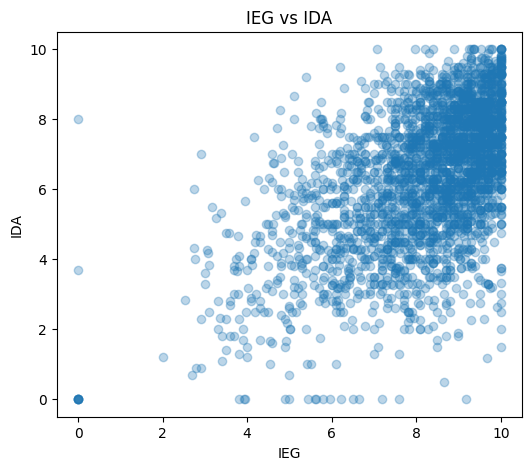

In [ ]:
# Correlacoes e scatter

def to_num(s):
    return pd.to_numeric(s, errors='coerce')

cols = ['IEG','IDA','IPV','IAA','IPS','IPP','INDE','IAN']
cols = [c for c in cols if c in base.columns]

df = base[cols].copy()
for c in cols:
    df[c] = to_num(df[c])

corr = df.corr(numeric_only=True)
display(corr)

# Scatter exemplo: IEG vs IDA
if set(['IEG','IDA']).issubset(df.columns):
    plt.figure(figsize=(6,5))
    plt.scatter(df['IEG'], df['IDA'], alpha=0.3)
    plt.title('IEG vs IDA')
    plt.xlabel('IEG')
    plt.ylabel('IDA')
    plt.show()


## 7) Ponto de virada (IPV)

Quais comportamentos (acadêmicos, emocionais, engajamento) mais influenciam IPV?

Sugestões:
- Regressão/árvore explicando IPV
- Feature importance (modelos)
- Análises por fase


,IEG,IDA,IPV,IAA,IPS,IPP,INDE,IAN
IEG,1.000000,0.539057,0.558200,0.133078,-0.046264,0.328542,0.789472,-0.060345
IDA,0.539057,1.000000,0.557072,0.115241,0.022485,0.369218,0.805507,0.118487
IPV,0.558200,0.557072,1.000000,0.062728,-0.048750,0.606649,0.767725,0.148880
IAA,0.133078,0.115241,0.062728,1.000000,0.157373,0.054461,0.413059,0.034162
IPS,-0.046264,0.022485,-0.048750,0.157373,1.000000,0.064209,0.230417,0.004548
IPP,0.328542,0.369218,0.606649,0.054461,0.064209,1.000000,0.637097,0.123398
INDE,0.789472,0.805507,0.767725,0.413059,0.230417,0.637097,1.000000,0.400511
IAN,-0.060345,0.118487,0.148880,0.034162,0.004548,0.123398,0.400511,1.000000


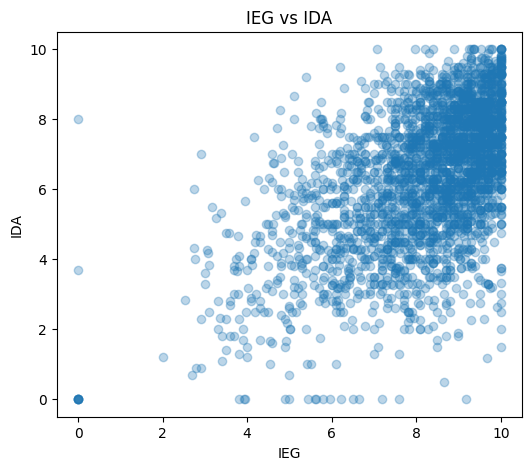

In [ ]:
# Correlacoes e scatter

def to_num(s):
    return pd.to_numeric(s, errors='coerce')

cols = ['IEG','IDA','IPV','IAA','IPS','IPP','INDE','IAN']
cols = [c for c in cols if c in base.columns]

df = base[cols].copy()
for c in cols:
    df[c] = to_num(df[c])

corr = df.corr(numeric_only=True)
display(corr)

# Scatter exemplo: IEG vs IDA
if set(['IEG','IDA']).issubset(df.columns):
    plt.figure(figsize=(6,5))
    plt.scatter(df['IEG'], df['IDA'], alpha=0.3)
    plt.title('IEG vs IDA')
    plt.xlabel('IEG')
    plt.ylabel('IDA')
    plt.show()


## 8) Multidimensionalidade (IDA + IEG + IPS + IPP) vs INDE

Quais combinações melhor explicam o desempenho global (INDE)?

Sugestões:
- Modelo de regressão simples pra INDE
- Importância de features
- Interações (ex.: alto IEG compensa IPS mais baixo?)


,IEG,IDA,IPV,IAA,IPS,IPP,INDE,IAN
IEG,1.000000,0.539057,0.558200,0.133078,-0.046264,0.328542,0.789472,-0.060345
IDA,0.539057,1.000000,0.557072,0.115241,0.022485,0.369218,0.805507,0.118487
IPV,0.558200,0.557072,1.000000,0.062728,-0.048750,0.606649,0.767725,0.148880
IAA,0.133078,0.115241,0.062728,1.000000,0.157373,0.054461,0.413059,0.034162
IPS,-0.046264,0.022485,-0.048750,0.157373,1.000000,0.064209,0.230417,0.004548
IPP,0.328542,0.369218,0.606649,0.054461,0.064209,1.000000,0.637097,0.123398
INDE,0.789472,0.805507,0.767725,0.413059,0.230417,0.637097,1.000000,0.400511
IAN,-0.060345,0.118487,0.148880,0.034162,0.004548,0.123398,0.400511,1.000000


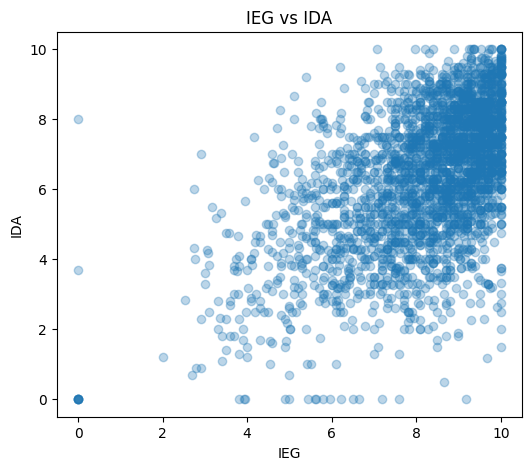

In [ ]:
# Correlacoes e scatter

def to_num(s):
    return pd.to_numeric(s, errors='coerce')

cols = ['IEG','IDA','IPV','IAA','IPS','IPP','INDE','IAN']
cols = [c for c in cols if c in base.columns]

df = base[cols].copy()
for c in cols:
    df[c] = to_num(df[c])

corr = df.corr(numeric_only=True)
display(corr)

# Scatter exemplo: IEG vs IDA
if set(['IEG','IDA']).issubset(df.columns):
    plt.figure(figsize=(6,5))
    plt.scatter(df['IEG'], df['IDA'], alpha=0.3)
    plt.title('IEG vs IDA')
    plt.xlabel('IEG')
    plt.ylabel('IDA')
    plt.show()


## 9) ML: previsao de risco de defasagem

Quais padrões permitem identificar alunos em risco antes da queda? Construir um modelo preditivo com probabilidade de risco.

Aqui entra o pipeline completo:
- Definir target `risco` (binário)
- Feature engineering
- Split treino/teste
- Modelagem
- Avaliação
- Export do modelo

**TODO crítico:** definir o que é “risco de defasagem”. Exemplos:
- `Defasagem <= -1`
- IAN acima de certo corte
- Queda de INDE/IDA vs ano anterior (se tu conseguir montar histórico por RA)


### 9.1) Criar alvo (target) de risco

Aqui tu define a regra. Vou te deixar uma default **bem razoável**: risco = `Defasagem <= -1` **OU** `IAN >= 7`.

Ajusta conforme tua leitura do problema/dicionário.


In [ ]:
# Definir target de risco (ajuste os cortes)

tmp = base.copy()

tmp['Defasagem_num'] = pd.to_numeric(tmp['Defasagemagem'] if 'Defasagemagem' in tmp.columns else tmp.get('Defasagem'), errors='coerce')
tmp['IAN_num'] = pd.to_numeric(tmp['IAN'], errors='coerce')

tmp = tmp.sort_values(['RA','ano_ref'])  # >>> NOVO (ordenar temporalmente)

tmp['IAN_futuro'] = tmp.groupby('RA')['IAN_num'].shift(-1)  # >>> NOVO

tmp['risco'] = (tmp['IAN_futuro'] >= 7).astype(int)  # >>> ALTERADO

tmp = tmp.dropna(subset=['IAN_futuro'])  # >>> NOVO (remover ultima observacao sem futuro)

### 9.2) Feature engineering (simples, mas decente)

- Categorias: `Fase`, `Turma`, `Gênero`, `Instituicao_Ensino`, `Pedra 20/21/22/23/24`, `Escola`...
- Numéricos: `IAA`, `IEG`, `IPS`, `IPP`, `IDA`, `IPV`, `INDE`, `Mat/Por/Ing`, `Idade`, etc.

Dica: começa simples. Depois tu incrementa.


In [ ]:
# Selecionar features

feature_cols = [
    'ano_ref','Fase','Turma','Gênero','Ano ingresso','Instituicao_Ensino',
    'IAA','IEG','IPS','IPP','IDA','IPV','INDE',
    'Mat','Por','Ing','Idade',
    'Pedra 20','Pedra 21','Pedra 22','Pedra 23','Pedra 2023','Pedra 2024',
    'Escola','Ativo/ Inativo'
]

# Manter só as que existem
feature_cols = [c for c in feature_cols if c in tmp.columns]

X = tmp[feature_cols].copy()
y = tmp['risco'].copy()

# Lista de colunas que deveriam ser numéricas
potential_num_cols = ['ano_ref','Ano ingresso','IAA','IEG','IPS','IPP','IDA','IPV','INDE','IAN','Mat','Por','Ing','Idade']

# Converter colunas numéricas para o tipo correto, coercing erros para NaN
# Isso resolve o problema de strings como 'INCLUIR' em colunas numéricas
num_cols = []
for col in potential_num_cols:
    if col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')
        num_cols.append(col)

# Categorical columns são as que sobram de feature_cols
cat_cols = [c for c in feature_cols if c not in num_cols]

# Converter explicitamente colunas categóricas para string para evitar TypeErrors no OneHotEncoder
for col in cat_cols:
    if col in X.columns:
        X[col] = X[col].astype(str)

print('Num:', num_cols)
print('Cat:', cat_cols)

Num: ['ano_ref', 'Ano ingresso', 'IAA', 'IEG', 'IPS', 'IPP', 'IDA', 'IPV', 'INDE', 'Mat', 'Por', 'Ing', 'Idade']
Cat: ['Fase', 'Turma', 'Gênero', 'Instituicao_Ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'Pedra 23', 'Pedra 2023', 'Pedra 2024', 'Escola', 'Ativo/ Inativo']


### 9.3) Treino/Teste + Pipeline

Dois modelos:
- **Logistic Regression** (baseline interpretável)
- **Random Forest** (não linear, costuma performar bem)

Tu escolhe o campeão pelo ROC-AUC / PR-AUC + matriz de confusão.


In [ ]:
from sklearn.model_selection import GroupShuffleSplit  # >>> NOVO

gss = GroupShuffleSplit(test_size=0.2, random_state=42)  # >>> NOVO

train_idx, test_idx = next(gss.split(X, y, groups=tmp['RA']))  # >>> NOVO

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]  # >>> ALTERADO
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]  # >>> ALTERADO

# Preprocess
numeric_tf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_tf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_tf, num_cols),
        ('cat', categorical_tf, cat_cols)
    ],
    remainder='drop'
)

# Modelos
logreg = LogisticRegression(max_iter=2000)
rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

pipe_logreg = Pipeline(steps=[('prep', preprocess), ('model', logreg)])
pipe_rf = Pipeline(steps=[('prep', preprocess), ('model', rf)])

# Treinar
pipe_logreg.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)

print('Treino ok')

Treino ok


### 9.4) Avaliação

A avaliação aqui é o que vai te salvar na apresentação: mostra métrica + trade-off (recall vs precision).



=== LogReg ===
ROC-AUC: 0.8699
PR-AUC : 0.889

Confusion matrix:
 [[ 92  41]
 [ 19 118]]

Report:
               precision    recall  f1-score   support

           0      0.829     0.692     0.754       133
           1      0.742     0.861     0.797       137

    accuracy                          0.778       270
   macro avg      0.785     0.777     0.776       270
weighted avg      0.785     0.778     0.776       270


=== RandomForest ===
ROC-AUC: 0.8744
PR-AUC : 0.884

Confusion matrix:
 [[ 98  35]
 [ 16 121]]

Report:
               precision    recall  f1-score   support

           0      0.860     0.737     0.794       133
           1      0.776     0.883     0.826       137

    accuracy                          0.811       270
   macro avg      0.818     0.810     0.810       270
weighted avg      0.817     0.811     0.810       270



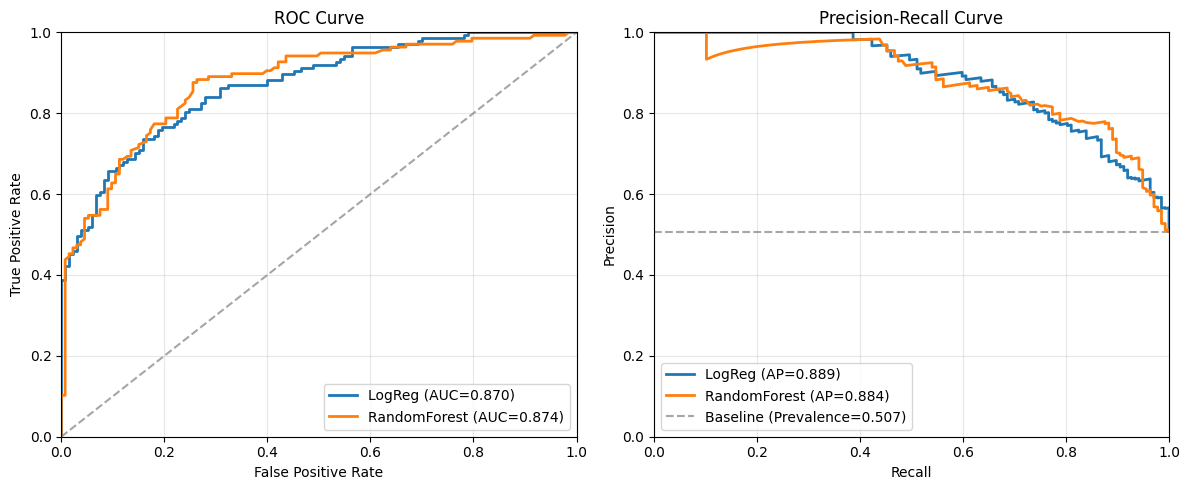

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)

def eval_model(name, model, X_test, y_test, plot=False):
    proba = model.predict_proba(X_test)[:, 1]

    precision, recall, thresholds = precision_recall_curve(y_test, proba)  # >>> NOVO

    f1 = 2*(precision*recall)/(precision+recall+1e-9)  # >>> NOVO
    best_threshold = thresholds[np.argmax(f1)]  # >>> NOVO

    pred = (proba >= best_threshold).astype(int)  # >>> ALTERADO

    roc = roc_auc_score(y_test, proba)
    ap = average_precision_score(y_test, proba)

    print(f'\n=== {name} ===')
    print('ROC-AUC:', round(roc, 4))
    print('PR-AUC :', round(ap, 4))
    print('\nConfusion matrix:\n', confusion_matrix(y_test, pred))
    print('\nReport:\n', classification_report(y_test, pred, digits=3))

    fpr, tpr, _ = roc_curve(y_test, proba)
    precision, recall, _ = precision_recall_curve(y_test, proba)

    return {
        "name": name,
        "fpr": fpr,
        "tpr": tpr,
        "precision": precision,
        "recall": recall,
        "roc_auc": roc,
        "pr_auc": ap
    }


def plot_curves(results, y_test):
    prevalence = np.mean(y_test)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # ROC
    ax = axes[0]
    for res in results:
        ax.plot(
            res["fpr"], res["tpr"],
            linewidth=2,
            label=f'{res["name"]} (AUC={res["roc_auc"]:.3f})'
        )

    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.7)
    ax.set_title('ROC Curve', fontsize=12)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.grid(alpha=0.3)
    ax.legend()

    # Precision-Recall
    ax = axes[1]
    for res in results:
        ax.plot(
            res["recall"], res["precision"],
            linewidth=2,
            label=f'{res["name"]} (AP={res["pr_auc"]:.3f})'
        )

    ax.hlines(
        prevalence, xmin=0, xmax=1,
        linestyle='--', color='gray', alpha=0.7,
        label=f'Baseline (Prevalence={prevalence:.3f})'
    )

    ax.set_title('Precision-Recall Curve', fontsize=12)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()


# Avaliação
results = []
results.append(eval_model('LogReg', pipe_logreg, X_test, y_test))
results.append(eval_model('RandomForest', pipe_rf, X_test, y_test))

plot_curves(results, y_test)

### 9.5) Export do modelo

Escolhe um modelo e salva. Esse arquivo é o que tu usa depois no Streamlit.


In [ ]:
# Escolha teu campeao aqui
best_model = pipe_rf

MODEL_OUT = Path('/content/modelo_risco_defasagem.joblib')
joblib.dump(best_model, MODEL_OUT)
print('Modelo salvo em:', MODEL_OUT)


Modelo salvo em: /content/modelo_risco_defasagem.joblib


## 10) Efetividade do programa (Quartzo/Agata/Ametista/Topazio)

Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases/pedras?

Sugestões:
- Comparar INDE/IDA/IEG/IPS/IPP por pedra e ano
- Se tiver histórico por RA, ver evolução individual


,ano_ref,Fase,IAN
0,2022,0,6.802632
1,2022,1,5.742188
2,2022,2,6.403226
3,2022,3,6.993243
4,2022,4,6.480263


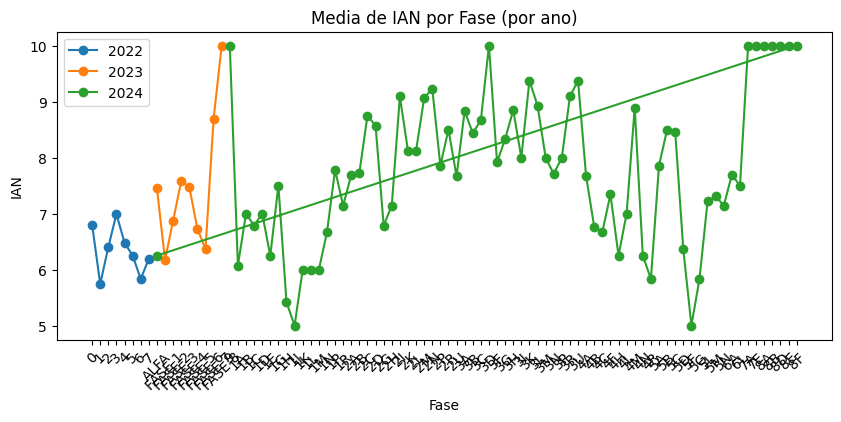

In [ ]:
# Exemplo: agregacao por ano e fase
metric = 'IAN'  # troque para 'IDA', 'INDE', etc.

tmp = base.copy()
tmp[metric] = pd.to_numeric(tmp[metric], errors='coerce')

grp = tmp.groupby(['ano_ref','Fase'])[metric].mean().reset_index()
display(grp.head())

# Plot simples
plt.figure(figsize=(10,4))
for yr, g in grp.groupby('ano_ref'):
    plt.plot(g['Fase'].astype(str), g[metric], marker='o', label=str(yr))
plt.title(f'Media de {metric} por Fase (por ano)')
plt.xlabel('Fase')
plt.ylabel(metric)
plt.legend()
plt.xticks(rotation=45)
plt.show()
